# F1 qualifying prediction with fastf1

Can we predict Saturday's **starting grid** on Friday evening - before a single qualifying lap has been run?

This notebook builds a complete machine-learning pipeline for exactly that, the day-before-quali use case:

1. **Collect** - qualifying classifications, race points, practice lap analysis (FP1/FP2 only) and sprint-qualifying results, pulled from the official F1 timing data with the `fastf1` library.
2. **Explore** - how much does Friday practice already reveal about Saturday?
3. **Engineer features** - practice pace, sprint quali, qualifying and championship history - all strictly known before qualifying starts.
4. **Model** - two histogram gradient boosters: an *anchor* model predicting the change vs each driver's last qualifying position, and a *direct* model predicting the absolute position.
5. **Backtest** - a rolling simulation of the season against the naive persistence baseline ("same grid as last weekend").
6. **Predict** - a full predicted grid, pole and front row for the target qualifying session.

The day-before-quali rule: features come from **FP1/FP2, sprint qualifying on sprint weekends, and earlier weekends only**. The sprint race is deliberately excluded - it runs on the same day as Grand Prix qualifying, so its result is not available the evening before.

Requirements: `pip install fastf1 pandas numpy scikit-learn matplotlib`

A command-line version of the same pipeline lives in `predict_grid.py`.

## 1. Setup

- `fastf1` stores downloaded timing data in a local `cache/` folder, so repeated runs are fast and don't re-hit the F1 API.
- Collected data is persisted to `data/quali_season_<year>.csv` and refreshed incrementally: after each new weekend, re-running the notebook only fetches the missing rounds.
- `SEASON` controls which championship is analysed (the 2026 season is in progress, so that is the default).
- The fastf1 log level is raised so download chatter doesn't drown the notebook output.

In [22]:
import warnings
from datetime import datetime, timedelta, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import fastf1
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CACHE_DIR = BASE_DIR / "cache"
DATA_DIR = BASE_DIR / "data"
CACHE_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

fastf1.Cache.enable_cache(str(CACHE_DIR))
fastf1.logger.set_log_level("WARNING")

SEASON = 2026
MIN_TRAIN_ROUNDS = 5
STINT_WINDOW = 5
STINT_MIN_LAPS = 3
COMPLETION_BUFFER = timedelta(hours=3)
PRACTICE_BUFFER = timedelta(hours=2)
PRACTICE_SESSIONS = ("FP1", "FP2")
NEUTRAL_POSITION = 11.5

PRACTICE_COLS = ["fp_race_pace_delta", "fp_best_delta", "fp_laps"]
SPRINT_QUALI_COLS = ["sprint_quali_pos", "sprint_quali_delta"]

FEATURES = [
    "fp_best_delta",
    "fp_race_pace_delta",
    "fp_laps",
    "team_fp_best_delta",
    "team_fp_race_pace_delta",
    "sprint_quali_pos",
    "sprint_quali_delta",
    "quali_pos_last",
    "quali_form_3",
    "quali_form_season",
    "team_quali_form_3",
    "team_quali_form_season",
    "driver_points_before",
    "team_points_before",
    "team_id",
]

RAW_COLUMNS = [
    "round",
    "event",
    "driver_number",
    "driver",
    "team",
    "quali_pos",
    "quali_time",
    "quali_delta",
    "points",
] + PRACTICE_COLS + SPRINT_QUALI_COLS

plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 12,
})

print("fastf1", fastf1.__version__, "| season", SEASON, "| target: qualifying")

fastf1 3.8.3 | season 2026 | target: qualifying


## 2. Collecting weekend data

For every **completed round** the notebook loads:

- **Qualifying** -> the classification (`quali_pos`, the prediction target) and each driver's best lap. The lap delta to pole is stored for reference only - it is *not* a feature, it is part of what we are predicting.
- **Race** -> championship `points` only, used to build the points-before features.
- **Practice (FP1/FP2)** -> clean laps (green flag, accurate timing, no pit in/out) produce `fp_best_delta` (fastest clean lap vs the session's fastest), `fp_race_pace_delta` (best rolling 5-lap average within a stint vs the session's best stint) and `fp_laps`. Sprint weekends only have FP1.
- **Sprint qualifying** (sprint weekends) -> `sprint_quali_pos` and `sprint_quali_delta`, derived from each driver's best SQ lap (fastf1 cannot populate SQ session results directly; the lap-derived order matches the official sprint grid exactly).

Details that matter:

- The model predicts the **qualifying classification**; the official starting grid can differ through gearbox/engine penalties.
- Drivers who set no qualifying time keep `quali_pos = NaN` and drop out of training; everyone entered is still predicted.
- Per-round frames are cached in `data/quali_season_2026.csv`; only rounds missing from that file are downloaded on each run.

In [23]:
def utc_now():
    return pd.Timestamp(datetime.now(timezone.utc)).replace(tzinfo=None)


def session_utc(row, name):
    for i in range(1, 6):
        if row.get(f"Session{i}") == name:
            value = row.get(f"Session{i}DateUtc")
            if pd.isna(value):
                return None
            return pd.Timestamp(value)
    return None


def practice_done_by(row, now):
    for name in ("Practice 2", "Practice 1"):
        utc = session_utc(row, name)
        if utc is not None and utc < now - PRACTICE_BUFFER:
            return True
    return False


def best_quali_seconds(qres, num):
    if num not in qres.index:
        return np.nan
    times = []
    for col in ("Q1", "Q2", "Q3"):
        if col in qres.columns:
            value = qres.at[num, col]
            if pd.notna(value):
                times.append(pd.Timedelta(value).total_seconds())
    return min(times) if times else np.nan


def pole_seconds(qres):
    times = [best_quali_seconds(qres, num) for num in qres.index]
    times = [t for t in times if not np.isnan(t)]
    return min(times) if times else np.nan


def _clean_practice_laps(session):
    laps = session.laps
    if laps is None or laps.empty:
        return pd.DataFrame()
    clean = laps[
        laps["LapTime"].notna()
        & laps["IsAccurate"].fillna(False)
        & laps["PitInTime"].isna()
        & laps["PitOutTime"].isna()
        & (laps["TrackStatus"].astype(str) == "1")
    ][["DriverNumber", "Stint", "LapNumber", "LapTime"]].copy()
    if clean.empty:
        return clean
    clean["DriverNumber"] = clean["DriverNumber"].astype(str)
    clean["seconds"] = clean["LapTime"].dt.total_seconds()
    return clean


def _practice_session_frame(session):
    clean = _clean_practice_laps(session)
    if clean.empty:
        return None
    best_lap = clean.groupby("DriverNumber")["seconds"].min()
    stint_best = {}
    for (num, _), group in clean.groupby(["DriverNumber", "Stint"]):
        if len(group) < STINT_MIN_LAPS:
            continue
        group = group.sort_values("LapNumber")
        pace = group["seconds"].rolling(STINT_WINDOW, min_periods=STINT_MIN_LAPS).mean().min()
        stint_best[num] = min(stint_best.get(num, np.inf), pace)
    if len(stint_best) < 3:
        return None
    stint = pd.Series(stint_best)
    return pd.DataFrame({
        "fp_best_delta": best_lap - best_lap.min(),
        "fp_laps": clean.groupby("DriverNumber").size(),
        "fp_race_pace_delta": stint - stint.min(),
    })


def practice_features(year, round_number, sessions=PRACTICE_SESSIONS):
    frames = []
    for identifier in sessions:
        try:
            session = fastf1.get_session(year, round_number, identifier)
            session.load(laps=True, telemetry=False, weather=False, messages=False)
            frame = _practice_session_frame(session)
        except Exception:
            frame = None
        if frame is not None:
            frames.append(frame)
    if not frames:
        return pd.DataFrame()
    combined = pd.concat(frames)
    return combined.groupby(level=0).agg(
        fp_race_pace_delta=("fp_race_pace_delta", "min"),
        fp_best_delta=("fp_best_delta", "min"),
        fp_laps=("fp_laps", "sum"),
    )


def practice_entrants(year, round_number, sessions=PRACTICE_SESSIONS):
    for identifier in sessions:
        try:
            session = fastf1.get_session(year, round_number, identifier)
            session.load(laps=False, telemetry=False, weather=False, messages=False)
            if not session.results.empty:
                return session.results
        except Exception:
            continue
    return None


def sprint_quali_features(year, round_number):
    try:
        sq = fastf1.get_session(year, round_number, "SQ")
        sq.load(laps=True, telemetry=False, weather=False, messages=False)
        laps = sq.laps
        if laps is not None and not laps.empty:
            clean = laps[laps["LapTime"].notna() & (laps["Deleted"] != True)]
            if not clean.empty:
                best = clean.groupby(clean["DriverNumber"].astype(str))["LapTime"].min()
                if not best.empty:
                    return pd.DataFrame({
                        "sprint_quali_pos": best.rank(method="min").astype(float),
                        "sprint_quali_delta": (best - best.min()).dt.total_seconds(),
                    })
    except Exception:
        pass
    try:
        sprint = fastf1.get_session(year, round_number, "S")
        sprint.load(laps=False, telemetry=False, weather=False, messages=False)
        results = sprint.results
        if not results.empty and results["GridPosition"].notna().any():
            pos = {}
            for num in results.index:
                grid = results.at[num, "GridPosition"]
                pos[str(num)] = float(grid) if pd.notna(grid) and grid > 0 else np.nan
            return pd.DataFrame({
                "sprint_quali_pos": pd.Series(pos),
                "sprint_quali_delta": np.nan,
            })
    except Exception:
        pass
    return pd.DataFrame()


def _merge_weekend_features(frame, year, round_number):
    practice = practice_features(year, round_number)
    if not practice.empty:
        for col in PRACTICE_COLS:
            frame[col] = frame["driver_number"].map(practice[col])
    sprint_quali = sprint_quali_features(year, round_number)
    if not sprint_quali.empty:
        for col in SPRINT_QUALI_COLS:
            frame[col] = frame["driver_number"].map(sprint_quali[col])
    return frame


def load_completed_round(year, round_number, event_name):
    quali = fastf1.get_session(year, round_number, "Q")
    quali.load(laps=False, telemetry=False, weather=False, messages=False)
    race = fastf1.get_session(year, round_number, "R")
    race.load(laps=False, telemetry=False, weather=False, messages=False)
    qres = quali.results
    rres = race.results
    pole = pole_seconds(qres)
    points_map = {}
    for num in rres.index:
        value = rres.at[num, "Points"]
        points_map[str(num)] = float(value) if pd.notna(value) else 0.0
    rows = []
    for num in qres.index:
        row = qres.loc[num]
        pos = row["Position"]
        rows.append({
            "round": round_number,
            "event": event_name,
            "driver_number": str(num),
            "driver": row["Abbreviation"],
            "team": row["TeamName"],
            "quali_pos": float(pos) if pd.notna(pos) else np.nan,
            "quali_time": best_quali_seconds(qres, num),
            "quali_delta": np.nan,
            "points": points_map.get(str(num), 0.0),
        })
    frame = pd.DataFrame(rows, columns=RAW_COLUMNS)
    frame["quali_delta"] = frame["quali_time"] - pole
    return _merge_weekend_features(frame, year, round_number)


def load_upcoming_round(year, round_number, event_name, fallback):
    results = practice_entrants(year, round_number)
    if results is not None:
        entries = [(str(num), results.at[num, "Abbreviation"], results.at[num, "TeamName"])
                   for num in results.index]
    else:
        entries = [(str(r.driver_number), r.driver, r.team) for r in fallback.itertuples()]
    rows = []
    for num, driver, team in entries:
        rows.append({
            "round": round_number,
            "event": event_name,
            "driver_number": num,
            "driver": driver,
            "team": team,
            "quali_pos": np.nan,
            "quali_time": np.nan,
            "quali_delta": np.nan,
            "points": 0.0,
        })
    frame = pd.DataFrame(rows, columns=RAW_COLUMNS)
    return _merge_weekend_features(frame, year, round_number)

In [24]:
def collect_season(year, schedule, refresh=False):
    path = DATA_DIR / f"quali_season_{year}.csv"
    now = utc_now()
    completed = []
    for _, ev in schedule.iterrows():
        race_utc = session_utc(ev, "Race")
        if race_utc is not None and race_utc < now - COMPLETION_BUFFER:
            completed.append((int(ev["RoundNumber"]), str(ev["EventName"])))

    cached = None
    if path.exists() and not refresh:
        candidate = pd.read_csv(path, dtype={"driver_number": str})
        if set(RAW_COLUMNS).issubset(candidate.columns):
            cached = candidate
        else:
            print("cached season file has an outdated schema, re-downloading")
    have = set(cached["round"].unique()) if cached is not None else set()

    todo = [(rn, name) for rn, name in completed if rn not in have]
    print(f"Season {year}: {len(completed)} completed weekends ({len(have)} cached, {len(todo)} to fetch)")

    frames = []
    for rn, name in todo:
        try:
            frame = load_completed_round(year, rn, name)
        except Exception as exc:
            print(f"  round {rn:>2} ({name}) skipped: {type(exc).__name__}: {exc}")
            continue
        if frame["quali_pos"].notna().sum() == 0:
            print(f"  round {rn:>2} ({name}) skipped: no classified quali results yet")
            continue
        print(f"  fetched round {rn:>2}  {name}")
        frames.append(frame)

    if cached is not None:
        frames.insert(0, cached)
    if not frames:
        return pd.DataFrame(columns=RAW_COLUMNS)

    data = pd.concat(frames, ignore_index=True)
    data = data.drop_duplicates(subset=["round", "driver_number"], keep="last")
    data = data.sort_values(["round", "driver_number"]).reset_index(drop=True)
    data.to_csv(path, index=False)
    return data

In [25]:
schedule = fastf1.get_event_schedule(SEASON, include_testing=False)
data = collect_season(SEASON, schedule)
if data.empty:
    SEASON -= 1
    print(f"no completed weekends yet this season, falling back to {SEASON}")
    schedule = fastf1.get_event_schedule(SEASON, include_testing=False)
    data = collect_season(SEASON, schedule)

print(f"dataset: {data['round'].nunique()} rounds, {len(data)} driver-quali rows")

Season 2026: 15 completed weekends (15 cached, 0 to fetch)
dataset: 15 rounds, 330 driver-quali rows


## 3. Understanding the data

Each row is one driver in one qualifying session. Before modelling, four questions:

- **Does Friday pace predict Saturday pace?** Scatter of `fp_best_delta` (fastest clean practice lap vs the session's fastest) against the qualifying position - the headline relationship for this model.
- **How stable is the grid weekend to weekend?** Histogram of `quali_pos - quali_pos_last`; the bulk sits near zero, which is exactly what the persistence baseline exploits.
- **Does long-run pace matter for one lap?** Scatter of `fp_race_pace_delta` against the qualifying position.
- **Does sprint quali carry over?** On sprint weekends: sprint quali position vs Grand Prix quali position, one day apart.

Finally, the championship context: points scored in races so far, coloured by team.

In [26]:
completed_round = int(data.loc[data["quali_pos"].notna(), "round"].max())
print(f"drivers seen      : {data['driver'].nunique()}")
print(f"teams             : {data['team'].nunique()}")
sprint_rows = data["sprint_quali_pos"].notna()
print(f"sprint quali rows : {sprint_rows.sum()} across {data.loc[sprint_rows, 'round'].nunique()} sprint weekends")
print(f"practice coverage : {data['fp_best_delta'].notna().mean():.0%} of rows")
data.head(12)

drivers seen      : 23
teams             : 11
sprint quali rows : 107 across 5 sprint weekends
practice coverage : 100% of rows


,round,event,driver_number,driver,team,quali_pos,quali_time,quali_delta,points,fp_race_pace_delta,fp_best_delta,fp_laps,sprint_quali_pos,sprint_quali_delta
0,1,Australian Grand Prix,1,NOR,McLaren,6.0,79.475,0.957,10.0,0.000000,1.065,19.0,NaN,NaN
1,1,Australian Grand Prix,10,GAS,Alpine,14.0,80.501,1.983,1.0,9.228333,2.438,28.0,NaN,NaN
2,1,Australian Grand Prix,11,PER,Cadillac,18.0,82.605,4.087,0.0,14.499667,4.353,5.0,NaN,NaN
3,1,Australian Grand Prix,12,ANT,Mercedes,2.0,78.811,0.293,18.0,0.000000,0.214,30.0,NaN,NaN
4,1,Australian Grand Prix,14,ALO,Aston Martin,17.0,81.969,3.451,0.0,11.471333,4.933,8.0,NaN,NaN
5,1,Australian Grand Prix,16,LEC,Ferrari,4.0,79.327,0.809,15.0,2.741667,0.000,41.0,NaN,NaN
6,1,Australian Grand Prix,18,STR,Aston Martin,NaN,NaN,NaN,0.0,13.932333,6.087,7.0,NaN,NaN
7,1,Australian Grand Prix,23,ALB,Williams,15.0,80.941,2.423,0.0,10.240200,2.118,37.0,NaN,NaN
8,1,Australian Grand Prix,27,HUL,Audi,11.0,80.303,1.785,0.0,1.961333,1.622,32.0,NaN,NaN
9,1,Australian Grand Prix,3,VER,Red Bull Racing,NaN,NaN,NaN,8.0,0.500400,0.522,20.0,NaN,NaN


In [27]:
session = fastf1.get_session(SEASON, completed_round, "R")
session.load(laps=False, telemetry=False, weather=False, messages=False)
TEAM_COLORS = {
    team: "#" + color
    for team, color in zip(session.results["TeamName"], session.results["TeamColor"])
}
TEAM_COLORS

{'Mercedes': '#00D7B6',
 'Red Bull Racing': '#4781D7',
 'Ferrari': '#ED1131',
 'Racing Bulls': '#6C98FF',
 'Haas F1 Team': '#9C9FA2',
 'Williams': '#1868DB',
 'Audi': '#F50537',
 'McLaren': '#F47600',
 'Cadillac': '#909090',
 'Alpine': '#00A1E8',
 'Aston Martin': '#229971'}

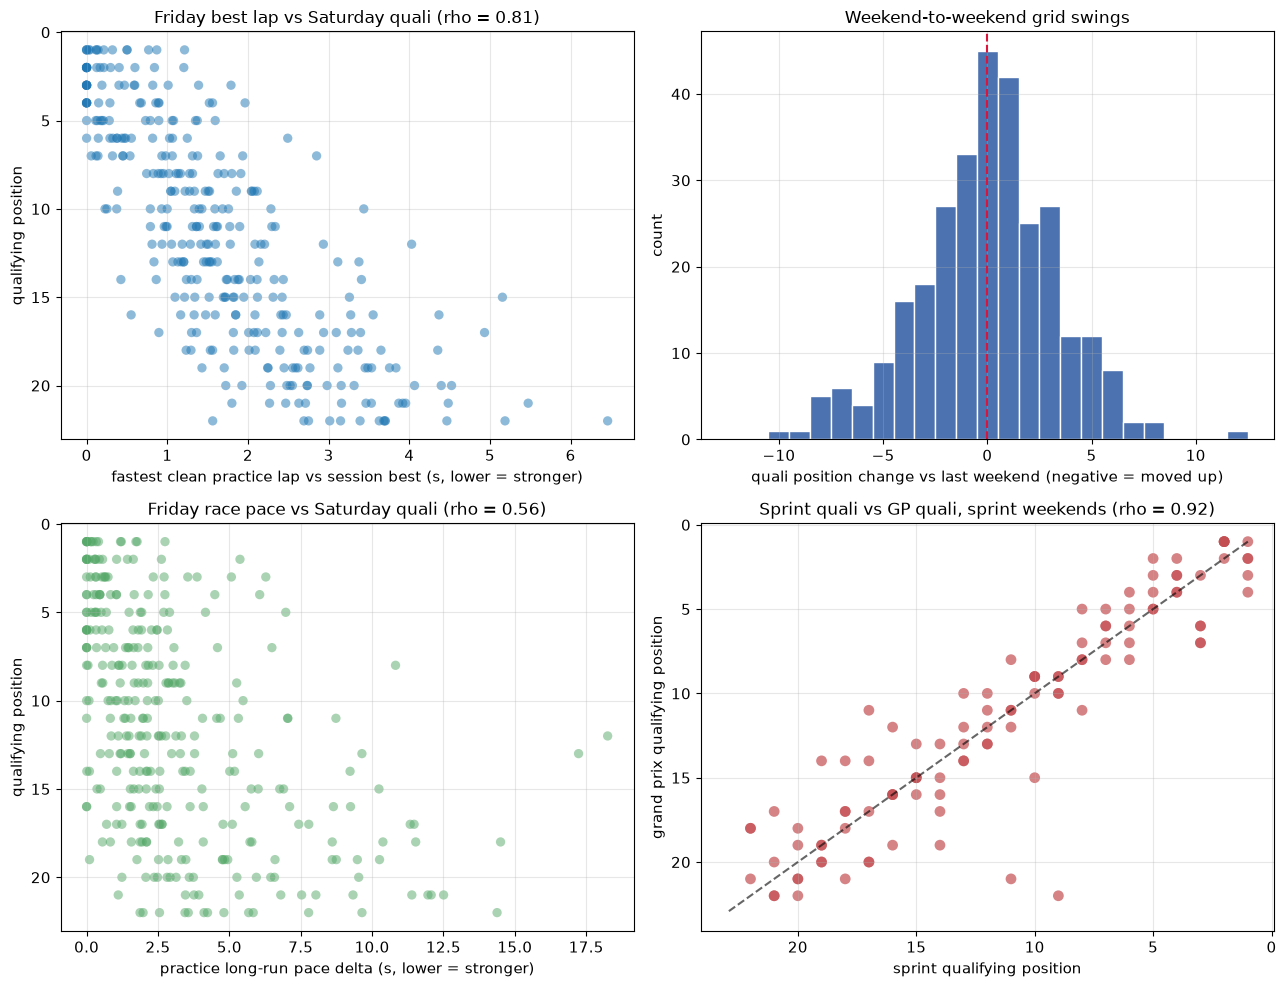

In [28]:
sorted_data = data.sort_values(["round", "driver_number"])
last_quali = sorted_data.groupby("driver_number")["quali_pos"].shift(1)
swings = sorted_data["quali_pos"] - last_quali

best = data[data["quali_pos"].notna() & data["fp_best_delta"].notna()]
rho_best = best["fp_best_delta"].corr(best["quali_pos"], method="spearman")
pace = data[data["quali_pos"].notna() & data["fp_race_pace_delta"].notna()]
rho_pace = pace["fp_race_pace_delta"].corr(pace["quali_pos"], method="spearman")
sprint = data[data["quali_pos"].notna() & data["sprint_quali_pos"].notna()]
rho_sprint = sprint["sprint_quali_pos"].corr(sprint["quali_pos"], method="spearman")

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0, 0].scatter(best["fp_best_delta"], best["quali_pos"], s=45, alpha=0.5, edgecolor="none")
axes[0, 0].invert_yaxis()
axes[0, 0].set(xlabel="fastest clean practice lap vs session best (s, lower = stronger)",
               ylabel="qualifying position",
               title=f"Friday best lap vs Saturday quali (rho = {rho_best:.2f})")

axes[0, 1].hist(swings.dropna(), bins=np.arange(-12.5, 13.5), color="#4c72b0", edgecolor="white")
axes[0, 1].axvline(0, c="crimson", ls="--")
axes[0, 1].set(xlabel="quali position change vs last weekend (negative = moved up)",
               ylabel="count", title="Weekend-to-weekend grid swings")

axes[1, 0].scatter(pace["fp_race_pace_delta"], pace["quali_pos"], s=45, alpha=0.5,
                   edgecolor="none", color="#55a868")
axes[1, 0].invert_yaxis()
axes[1, 0].set(xlabel="practice long-run pace delta (s, lower = stronger)",
               ylabel="qualifying position",
               title=f"Friday race pace vs Saturday quali (rho = {rho_pace:.2f})")

axes[1, 1].scatter(sprint["sprint_quali_pos"], sprint["quali_pos"], s=60, alpha=0.7,
                   edgecolor="none", color="#c44e52")
axes[1, 1].plot([1, 23], [1, 23], ls="--", c="black", alpha=0.6)
axes[1, 1].invert_xaxis()
axes[1, 1].invert_yaxis()
axes[1, 1].set(xlabel="sprint qualifying position", ylabel="grand prix qualifying position",
               title=f"Sprint quali vs GP quali, sprint weekends (rho = {rho_sprint:.2f})")

fig.tight_layout()
plt.show()

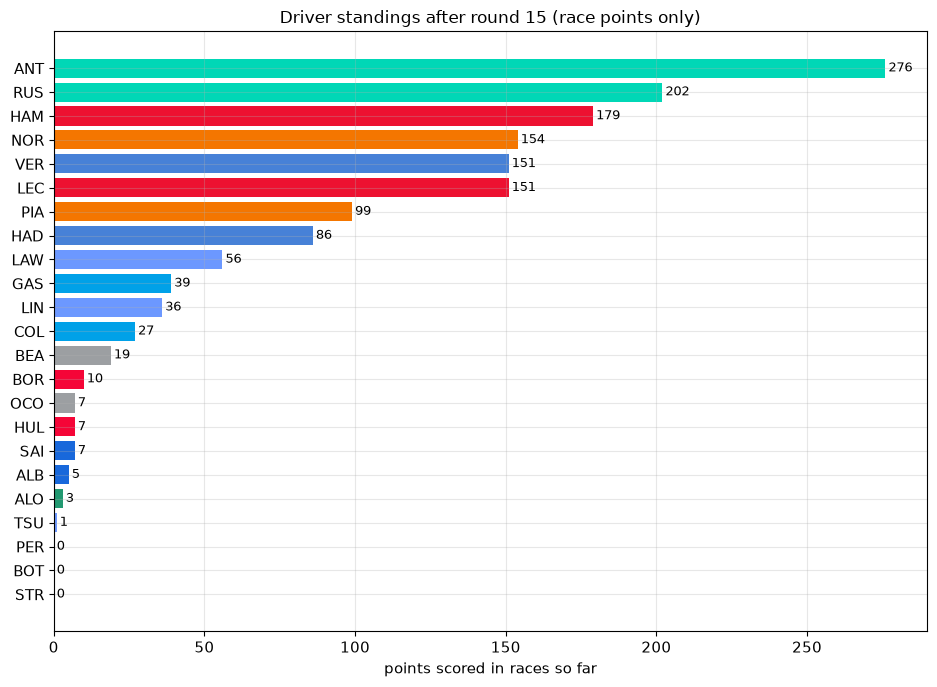

In [29]:
points = data.groupby("driver", as_index=False)["points"].sum()
points["team"] = points["driver"].map(data.sort_values("round").groupby("driver")["team"].last())
points = points.sort_values("points")
colors = [TEAM_COLORS.get(t, "#999999") for t in points["team"]]

fig, ax = plt.subplots(figsize=(9.5, 7))
ax.barh(points["driver"], points["points"], color=colors)
for y, v in enumerate(points["points"]):
    ax.text(v + 1, y, f"{v:.0f}", va="center", fontsize=9)
ax.set(xlabel="points scored in races so far",
       title=f"Driver standings after round {completed_round} (race points only)")
fig.tight_layout()
plt.show()

## 4. Feature engineering

Every feature is computed **strictly from information available before qualifying** - by design, the evening before:

| feature | meaning |
|---|---|
| `fp_best_delta` | fastest clean practice lap minus that session's fastest lap (best across FP1/FP2) - the single-lap pace signal |
| `fp_race_pace_delta` | best rolling 5-lap average within a practice stint, relative to the fastest stint in that session (best across FP1/FP2) |
| `fp_laps` | clean practice laps completed across FP1/FP2 |
| `team_fp_best_delta` / `team_fp_race_pace_delta` | the two pace measures averaged over both cars of the driver's team |
| `sprint_quali_pos` | sprint weekends only: sprint qualifying position |
| `sprint_quali_delta` | sprint weekends only: best sprint-quali lap minus SQ pole (seconds) |
| `quali_pos_last` | the driver's qualifying position in the previous round - the anchor |
| `quali_form_3` / `quali_form_season` | mean qualifying position over the previous 3 rounds / the whole season so far |
| `team_quali_form_3` / `team_quali_form_season` | the same rolling/expanding means for the team's cars |
| `driver_points_before` / `team_points_before` | championship points scored before this weekend (grand prix only) |
| `team_id` | the constructor, as a categorical feature |

Sprint-quali features exist only on sprint weekends (5 of the 15 completed rounds in 2026) and are `NaN` elsewhere; histogram gradient boosting consumes missing values natively, so no imputation is needed.

Leakage protection: the history features use `shift(1)` inside each driver's sequence, so a weekend is never described using its own qualifying result. Practice and sprint qualifying happen *before* GP qualifying, so using them for the same weekend is legitimate day-before-quali information.

In [30]:
def build_features(data):
    df = data.copy()
    df["driver_number"] = df["driver_number"].astype(str)
    df = df.sort_values(["round", "driver_number"]).reset_index(drop=True)
    df["team_id"] = pd.factorize(df["team"])[0]
    df["team_fp_best_delta"] = df.groupby(["round", "team"], sort=False)["fp_best_delta"].transform("mean")
    df["team_fp_race_pace_delta"] = df.groupby(["round", "team"], sort=False)["fp_race_pace_delta"].transform("mean")
    df["team_quali_mean"] = df.groupby(["round", "team"], sort=False)["quali_pos"].transform("mean")
    df["team_points"] = df.groupby(["round", "team"], sort=False)["points"].transform("sum")
    by_driver = df.groupby("driver_number", sort=False)
    df["quali_pos_last"] = by_driver["quali_pos"].transform(lambda s: s.shift(1))
    df["quali_form_3"] = by_driver["quali_pos"].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
    df["quali_form_season"] = by_driver["quali_pos"].transform(lambda s: s.shift(1).expanding(min_periods=1).mean())
    df["driver_points_before"] = by_driver["points"].transform(lambda s: s.cumsum().shift(1)).fillna(0.0)
    df["team_quali_form_3"] = by_driver["team_quali_mean"].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
    df["team_quali_form_season"] = by_driver["team_quali_mean"].transform(lambda s: s.shift(1).expanding(min_periods=1).mean())
    df["team_points_before"] = by_driver["team_points"].transform(lambda s: s.cumsum().shift(1)).fillna(0.0)
    return df


def anchor_value(rows):
    return rows["quali_pos_last"].fillna(rows["quali_form_season"]).fillna(NEUTRAL_POSITION)

In [31]:
features = build_features(data)
print(features.shape)
features[["driver", "team", "fp_best_delta", "fp_race_pace_delta", "sprint_quali_pos",
          "quali_pos_last", "quali_form_3", "driver_points_before", "quali_pos"]].tail(22)

(330, 26)


,driver,team,fp_best_delta,fp_race_pace_delta,sprint_quali_pos,quali_pos_last,quali_form_3,driver_points_before,quali_pos
308,NOR,McLaren,1.594,4.163467,NaN,1.0,3.666667,154.0,5.0
309,GAS,Alpine,1.656,4.584417,NaN,14.0,8.666667,39.0,7.0
310,PER,Cadillac,2.279,5.264333,NaN,19.0,20.333333,0.0,20.0
311,ANT,Mercedes,0.552,0.000000,NaN,2.0,4.000000,266.0,16.0
312,ALO,Aston Martin,2.448,8.746250,NaN,18.0,19.000000,3.0,19.0
313,LEC,Ferrari,0.404,1.636000,NaN,5.0,5.000000,139.0,2.0
314,STR,Aston Martin,3.160,5.347333,NaN,NaN,20.500000,0.0,21.0
315,ALB,Williams,1.552,5.116467,NaN,16.0,16.666667,5.0,13.0
316,HUL,Audi,1.534,0.831500,NaN,11.0,12.333333,7.0,18.0
317,VER,Red Bull Racing,0.827,0.000000,NaN,3.0,5.333333,133.0,8.0


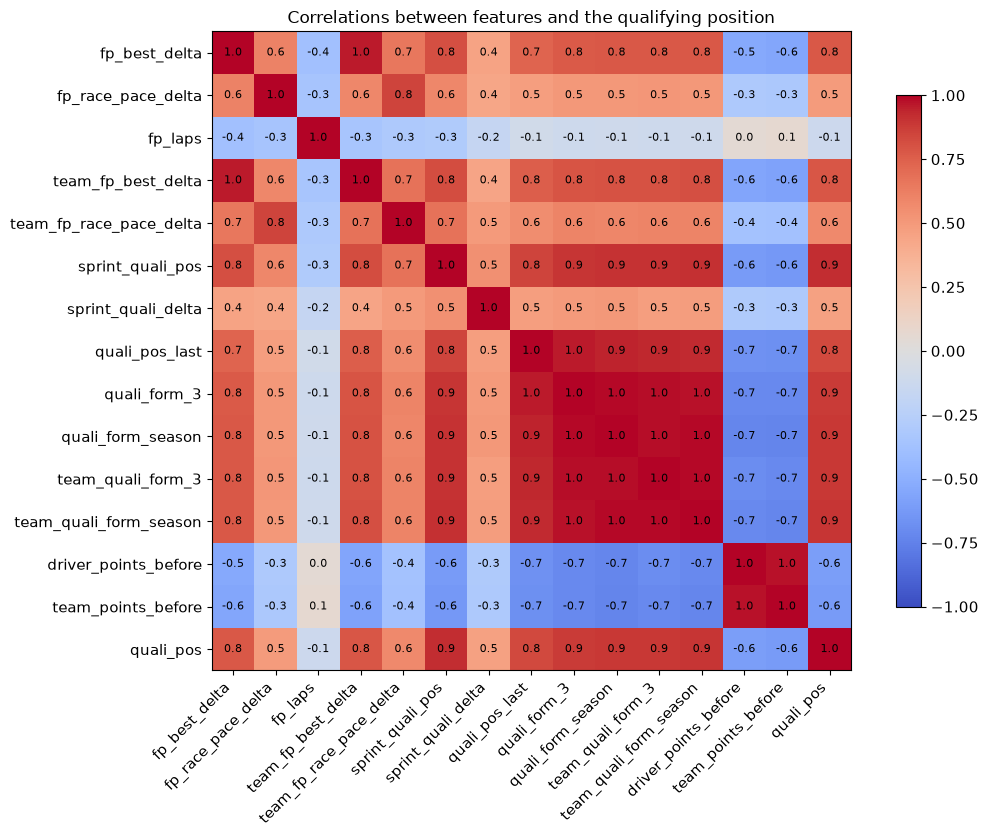

In [32]:
corr_cols = [f for f in FEATURES if f != "team_id"] + ["quali_pos"]
corr = features[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8.5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols)), corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.1f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, shrink=0.8)
ax.grid(False)
ax.set(title="Correlations between features and the qualifying position")
fig.tight_layout()
plt.show()

## 5. The models

Two gradient-boosting models share the same features but differ in their target:

- **anchor model** - predicts the *change vs each driver's last qualifying position* (`quali_pos - quali_pos_last`); the predicted score is `last quali position + prediction`. The anchor bakes in the strongest prior - grids are sticky weekend to weekend - so every move the model makes is a claim that Friday pace justifies it.
- **direct model** - predicts the **absolute qualifying position** straight from the features. It must learn the whole mapping from practice to quali itself, giving it more freedom to promote a surprise pace-setter - and more room to be wrong when the data is thin.

Both use `HistGradientBoostingRegressor` (native missing-value and categorical handling, well suited to a few hundred rows) with absolute-error loss, shallow trees (`max_leaf_nodes=15`), `min_samples_leaf=20`, 150 boosting iterations and L2 regularisation - keeping a 15-feature model honest on ~300 training rows. Drivers with no quali history (round 1, rookies) get a neutral anchor of 11.5.

Predictions become a grid by **ranking** the predicted scores. The naive baseline in every comparison is **persistence**: "everyone qualifies where they did last weekend".

In [33]:
def make_model():
    return HistGradientBoostingRegressor(
        loss="absolute_error",
        learning_rate=0.08,
        max_iter=150,
        max_leaf_nodes=15,
        min_samples_leaf=20,
        l2_regularization=1.0,
        categorical_features=[FEATURES.index("team_id")],
        random_state=42,
    )


def train_model(features, target_round, mode="anchor"):
    if mode == "anchor":
        train = features[
            (features["round"] < target_round)
            & features["quali_pos"].notna()
            & features["quali_pos_last"].notna()
        ]
        target = (train["quali_pos"] - train["quali_pos_last"]).to_numpy(dtype=float)
    else:
        train = features[
            (features["round"] < target_round)
            & features["quali_pos"].notna()
        ]
        target = train["quali_pos"].to_numpy(dtype=float)
    if train.empty:
        raise ValueError(f"no training data before round {target_round}")
    model = make_model()
    model.fit(train[FEATURES].to_numpy(dtype=float), target)
    return model, train


def predict_round(model, features, target_round, mode="anchor"):
    rows = features[features["round"] == target_round].copy()
    rows = rows.sort_values(["driver_number"])
    rows["model_output"] = model.predict(rows[FEATURES].to_numpy(dtype=float))
    if mode == "anchor":
        anchor = anchor_value(rows)
        rows["anchor"] = anchor
        rows["pred_score"] = anchor + rows["model_output"]
    else:
        rows["pred_score"] = rows["model_output"]
    rows["pred_pos"] = rows["pred_score"].rank(method="first").astype(int)
    return rows.sort_values("pred_pos")


def rank_corr(a, b):
    ra = pd.Series(a).rank().to_numpy()
    rb = pd.Series(b).rank().to_numpy()
    if np.std(ra) == 0 or np.std(rb) == 0:
        return np.nan
    return float(np.corrcoef(ra, rb)[0, 1])

## 6. Rolling backtest - anchor vs direct vs persistence

The season is simulated round by round with **no look-ahead**: for round *r*, both models are trained only on rounds `1..r-1`, predict round *r*'s qualifying, then move on. This mirrors exactly how the notebook would be used on a Friday evening.

Metrics per round, for **both models and the persistence baseline** ("same grid as last weekend"):

- **position MAE** - mean absolute error between predicted and actual qualifying positions of all classified drivers.
- **podium** - how many of the actual top-3 qualifiers the predicted top-3 contains (0-3).
- **pole** - whether the predicted P1 took pole.
- **rank corr** - Spearman correlation between predicted and actual qualifying orders.

In [34]:
def run_backtest(features, min_train_rounds=MIN_TRAIN_ROUNDS):
    rounds = sorted(features["round"].unique())
    records = []
    for r in rounds:
        if sum(1 for x in rounds if x < r) < min_train_rounds:
            continue
        try:
            anchor_model, _ = train_model(features, r, "anchor")
            direct_model, _ = train_model(features, r, "direct")
        except ValueError:
            continue
        anchor = predict_round(anchor_model, features, r, "anchor")
        direct = predict_round(direct_model, features, r, "direct")
        anchor_scored = anchor[anchor["quali_pos"].notna()]
        direct_scored = direct[direct["quali_pos"].notna()]
        pole_row = features.loc[(features["round"] == r) & (features["quali_pos"] == 1), "driver"]
        if anchor_scored.empty or pole_row.empty:
            continue
        pole = pole_row.iloc[0]
        actual_top3 = set(features.loc[(features["round"] == r) & (features["quali_pos"] <= 3), "driver"])
        persistence = anchor_value(anchor_scored).rank(method="first")
        records.append({
            "round": r,
            "event": str(features.loc[features["round"] == r, "event"].iloc[0]),
            "anchor_mae": float((anchor_scored["pred_pos"] - anchor_scored["quali_pos"]).abs().mean()),
            "direct_mae": float((direct_scored["pred_pos"] - direct_scored["quali_pos"]).abs().mean()),
            "persistence_mae": float((persistence - anchor_scored["quali_pos"]).abs().mean()),
            "anchor_podium": len(actual_top3 & set(anchor.head(3)["driver"])),
            "direct_podium": len(actual_top3 & set(direct.head(3)["driver"])),
            "anchor_pole": 1 if anchor.iloc[0]["driver"] == pole else 0,
            "direct_pole": 1 if direct.iloc[0]["driver"] == pole else 0,
            "anchor_corr": rank_corr(anchor_scored["pred_pos"], anchor_scored["quali_pos"]),
            "direct_corr": rank_corr(direct_scored["pred_pos"], direct_scored["quali_pos"]),
        })
    return pd.DataFrame(records)

In [35]:
bt = run_backtest(features)
display(bt.round(2))
print()
n = len(bt)
print(f"{'':<28} {'anchor':>7} {'direct':>8} {'last-quali':>10}")
print(f"{'position MAE':<28} {bt['anchor_mae'].mean():>7.2f} {bt['direct_mae'].mean():>8.2f} {bt['persistence_mae'].mean():>10.2f}")
print(f"{'podium hit rate':<28} {bt['anchor_podium'].sum() / (3 * n):>6.0%} {bt['direct_podium'].sum() / (3 * n):>7.0%}")
print(f"{'pole hit rate':<28} {bt['anchor_pole'].mean():>6.0%} {bt['direct_pole'].mean():>7.0%}")
print(f"{'rank correlation':<28} {bt['anchor_corr'].mean():>7.2f} {bt['direct_corr'].mean():>8.2f}")

,round,event,anchor_mae,direct_mae,persistence_mae,anchor_podium,direct_podium,anchor_pole,direct_pole,anchor_corr,direct_corr
0,6,Monaco Grand Prix,3.09,2.27,3.09,1,2,0,1,0.85,0.90
1,7,Barcelona Grand Prix,2.27,1.82,2.73,1,2,0,1,0.88,0.93
2,8,Austrian Grand Prix,1.64,2.00,1.55,1,1,1,0,0.94,0.92
3,9,British Grand Prix,1.73,1.73,1.45,2,2,0,0,0.95,0.92
4,10,Belgian Grand Prix,1.73,1.55,1.73,1,2,1,1,0.93,0.94
5,11,Hungarian Grand Prix,1.73,2.00,2.36,2,2,0,0,0.95,0.92
6,12,Dutch Grand Prix,1.82,1.36,1.82,2,2,1,0,0.92,0.96
7,13,Italian Grand Prix,3.09,2.64,3.09,1,1,0,0,0.79,0.85
8,14,Spanish Grand Prix,2.55,2.20,2.90,0,1,0,0,0.79,0.89
9,15,Azerbaijan Grand Prix,3.55,3.91,4.00,2,1,1,1,0.70,0.69



                              anchor   direct last-quali
position MAE                    2.32     2.15       2.47
podium hit rate                 43%     53%
pole hit rate                   40%     40%
rank correlation                0.87     0.89


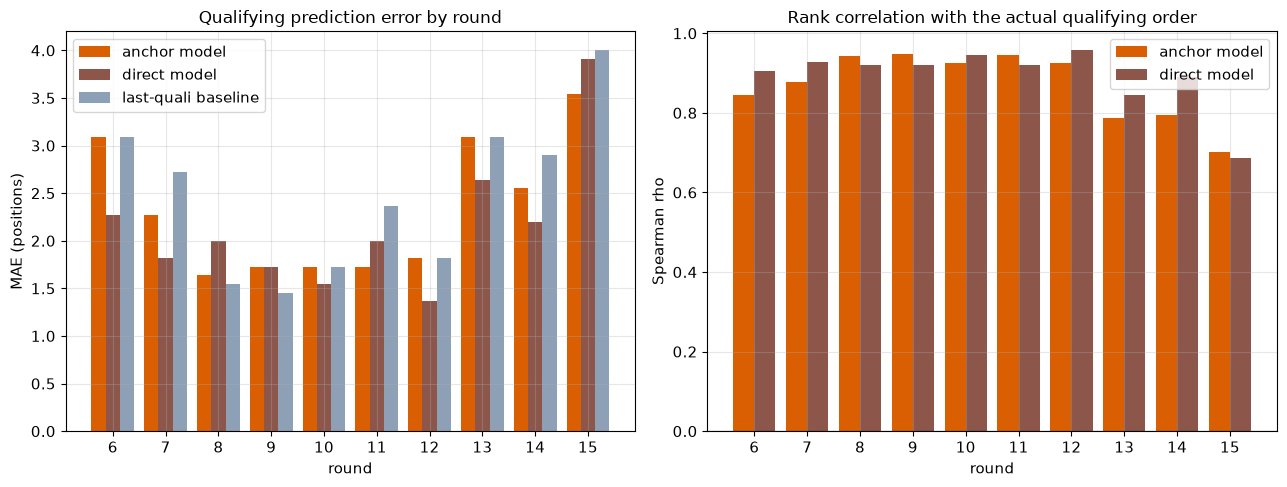

In [36]:
x = np.arange(len(bt))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(x - 0.27, bt["anchor_mae"], width=0.27, label="anchor model", color="#d95f02")
axes[0].bar(x, bt["direct_mae"], width=0.27, label="direct model", color="#8c564b")
axes[0].bar(x + 0.27, bt["persistence_mae"], width=0.27, label="last-quali baseline", color="#8ea0b5")
axes[0].set_xticks(x, bt["round"])
axes[0].set(xlabel="round", ylabel="MAE (positions)", title="Qualifying prediction error by round")
axes[0].legend()

axes[1].bar(x - 0.2, bt["anchor_corr"], width=0.4, label="anchor model", color="#d95f02")
axes[1].bar(x + 0.2, bt["direct_corr"], width=0.4, label="direct model", color="#8c564b")
axes[1].axhline(0, c="black", lw=0.8)
axes[1].set_xticks(x, bt["round"])
axes[1].set(xlabel="round", ylabel="Spearman rho",
            title="Rank correlation with the actual qualifying order")
axes[1].legend()
fig.tight_layout()
plt.show()

## 7. Predicting a qualifying session

The notebook picks a target automatically:

- If the **next round's qualifying** has not happened yet, that session is predicted for real - the day-before-quali use case (features: FP1/FP2, sprint quali if the weekend has one, and history). If Friday practice has not run yet, a note is printed and the prediction relies on historical form only.
- Otherwise it demonstrates on the **last completed qualifying**, so the prediction can be scored against the actual result.

Set `TARGET_ROUND` below to force a specific round instead.

In the result table, `anchor` and `direct` are the two models' predicted positions, `last_q` is the driver's previous qualifying position (the anchor), and `anchor_err` is the anchor model's error vs the actual result (negative = the model underrated the driver).

The charts below show, in order: where each model expects the grid to change vs last weekend, then the **final predicted grids** of both models side by side on one grid card (with the actual grid, or the last quali grid in day-before-quali mode, as a reference row - the grey lines connect each driver's two predicted slots, so disagreements stand out).

In [37]:
TARGET_ROUND = 15

now = utc_now()
completed_rounds = set(data.loc[data["quali_pos"].notna(), "round"].unique())
upcoming_rows = [row for _, row in schedule.iterrows()
                 if session_utc(row, "Race") is not None and session_utc(row, "Race") > now]

if TARGET_ROUND is not None:
    target_round = TARGET_ROUND
    row = schedule[schedule["RoundNumber"] == target_round].iloc[0]
    event_name = str(row["EventName"])
    quali_utc = session_utc(row, "Qualifying")
    if quali_utc is not None and quali_utc < now:
        if target_round in completed_rounds:
            mode = "post"
        else:
            raise SystemExit(f"round {target_round} happened recently but is not in the cache yet, retry in a few hours")
    else:
        mode = "pre"
elif upcoming_rows and (session_utc(upcoming_rows[0], "Qualifying") is None
                        or session_utc(upcoming_rows[0], "Qualifying") > now):
    row = upcoming_rows[0]
    target_round = int(row["RoundNumber"])
    event_name = str(row["EventName"])
    mode = "pre"
    if not practice_done_by(row, now):
        print(f"practice for the next round ({event_name}) has not finished yet,")
        print("predictions will rely on historical form only - run again after FP2 for best results")
    else:
        print(f"next up: {event_name} - practice done, predicting its qualifying")
else:
    if upcoming_rows:
        print(f"qualifying for the next round ({upcoming_rows[0]['EventName']}) already happened,")
        print("so the notebook demonstrates on the last completed qualifying instead")
    else:
        print(f"the {SEASON} season is finished, demonstrating on the final round")
    target_round = int(max(completed_rounds))
    event_name = str(data.loc[data["round"] == target_round, "event"].iloc[0])
    mode = "post"

print(f"target: round {target_round} - {event_name} - "
      f"{'day-before-quali prediction' if mode == 'pre' else 'completed weekend, scored vs the actual quali result'}")

target: round 15 - Azerbaijan Grand Prix - completed weekend, scored vs the actual quali result


In [38]:
if mode == "pre":
    fallback = data[data["round"] == int(max(completed_rounds))]
    upcoming = load_upcoming_round(SEASON, target_round, event_name, fallback)
    model_data = pd.concat([data[data["round"] != target_round], upcoming], ignore_index=True)
else:
    model_data = data

features_final = build_features(model_data)
anchor_model, train_set = train_model(features_final, target_round, "anchor")
direct_model, _ = train_model(features_final, target_round, "direct")
anchor = predict_round(anchor_model, features_final, target_round, "anchor")
direct = predict_round(direct_model, features_final, target_round, "direct")

result = pd.DataFrame({
    "anchor": anchor["pred_pos"].to_numpy(),
    "direct": anchor["driver"].map(direct.set_index("driver")["pred_pos"]).to_numpy(),
    "driver": anchor["driver"].to_numpy(),
    "team": anchor["team"].to_numpy(),
    "last_q": anchor["quali_pos_last"].round().astype("Int64").to_numpy(),
})
if mode == "post":
    result["actual"] = anchor["quali_pos"].astype("Int64").to_numpy()
    result["anchor_err"] = (anchor["pred_pos"] - anchor["quali_pos"]).round().astype("Int64").to_numpy()

print(f"predicted pole (anchor model) : {result.iloc[0]['driver']}")
print(f"predicted pole (direct model) : {result.sort_values('direct').iloc[0]['driver']}")
if mode == "post":
    pole = features_final.loc[(features_final["round"] == target_round) & (features_final["quali_pos"] == 1), "driver"]
    if not pole.empty:
        print(f"actual pole                   : {pole.iloc[0]}")
result

predicted pole (anchor model) : RUS
predicted pole (direct model) : RUS
actual pole                   : RUS


,anchor,direct,driver,team,last_q,actual,anchor_err
0,1,1,RUS,Mercedes,6.0,1,0
1,2,2,ANT,Mercedes,2.0,16,-14
2,3,4,LEC,Ferrari,5.0,2,1
3,4,5,HAM,Ferrari,4.0,6,-2
4,5,7,NOR,McLaren,1.0,5,0
5,6,3,VER,Red Bull Racing,3.0,8,-2
6,7,6,PIA,McLaren,7.0,3,4
7,8,10,LAW,Racing Bulls,8.0,12,-4
8,9,8,HAD,Red Bull Racing,8.0,4,5
9,10,9,LIN,Racing Bulls,10.0,15,-5


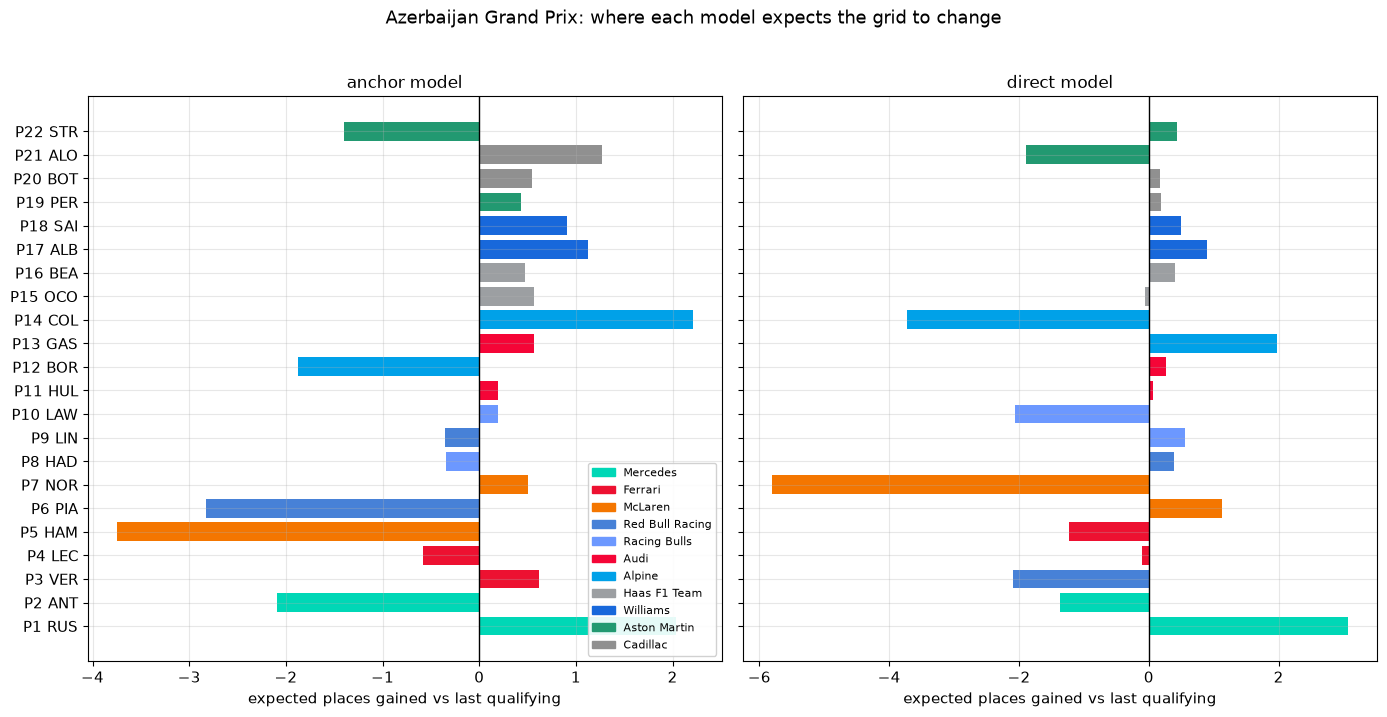

In [39]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
for ax, pred, name in ((axes[0], anchor, "anchor model"), (axes[1], direct, "direct model")):
    ordered = pred.sort_values("pred_pos")
    y = np.arange(len(ordered))
    colors = [TEAM_COLORS.get(t, "#999999") for t in ordered["team"]]
    ax.barh(y, anchor_value(ordered) - ordered["pred_score"], color=colors)
    ax.set_yticks(y, [f"P{p} {d}" for p, d in zip(ordered["pred_pos"], ordered["driver"])])
    ax.invert_yaxis()
    ax.axvline(0, c="black", lw=1)
    ax.set(xlabel="expected places gained vs last qualifying", title=name)
handles = [Patch(color=TEAM_COLORS.get(t, "#999999"), label=t) for t in anchor["team"].unique()]
axes[0].legend(handles=handles, loc="lower right", fontsize=8, framealpha=0.9)
fig.suptitle(f"{event_name}: where each model expects the grid to change", y=1.02)
fig.tight_layout()
plt.show()

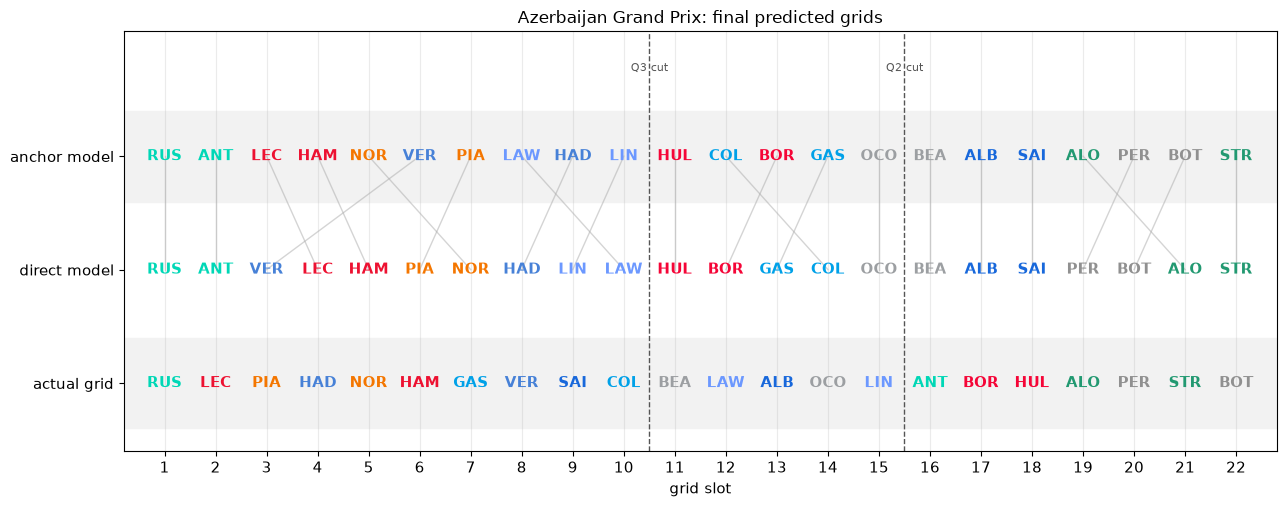

In [40]:
fig, ax = plt.subplots(figsize=(13, 5.2))

rows = [("anchor model", anchor, "pred_pos"),
        ("direct model", direct, "pred_pos")]
if mode == "post":
    rows.append(("actual grid", anchor, "quali_pos"))
else:
    rows.append(("last quali grid", anchor, "quali_pos_last"))

n_rows = len(rows)
for i, (name, frame, col) in enumerate(rows):
    y = n_rows - 1 - i
    ax.axhspan(y - 0.4, y + 0.4, color="#f2f2f2" if i % 2 == 0 else "white", zorder=0)
    for _, row in frame.sort_values(col).iterrows():
        if pd.isna(row[col]):
            continue
        ax.annotate(row["driver"], (row[col], y), ha="center", va="center",
                    fontsize=11, fontweight="bold",
                    color=TEAM_COLORS.get(row["team"], "#333333"), zorder=3)

direct_pos = direct.set_index("driver")["pred_pos"]
for _, row in anchor.iterrows():
    dpos = direct_pos.get(row["driver"])
    if pd.notna(dpos):
        ax.plot([row["pred_pos"], dpos], [n_rows - 1, n_rows - 2],
                lw=1, c="#aaaaaa", alpha=0.5, zorder=1)

ax.axvline(10.5, ls="--", c="#555555", lw=1, zorder=2)
ax.axvline(15.5, ls="--", c="#555555", lw=1, zorder=2)
ax.text(10.5, n_rows - 0.25, "Q3 cut", fontsize=8, color="#555555", ha="center")
ax.text(15.5, n_rows - 0.25, "Q2 cut", fontsize=8, color="#555555", ha="center")

ax.set_yticks(range(n_rows), [name for name, _, _ in rows][::-1])
ax.set_xlim(0.2, 22.8)
ax.set_xticks(range(1, 23))
ax.set_ylim(-0.6, n_rows + 0.1)
ax.xaxis.grid(True, alpha=0.25)
ax.yaxis.grid(False)
ax.set(xlabel="grid slot", title=f"{event_name}: final predicted grids")
fig.tight_layout()
plt.show()

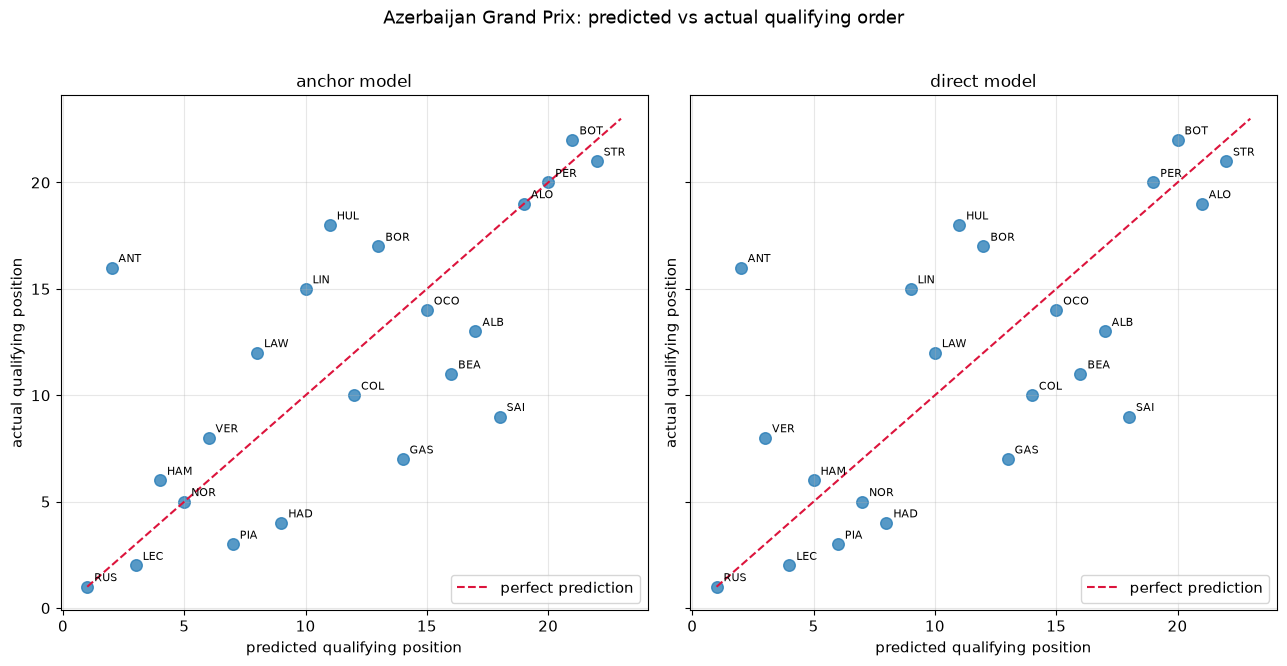

In [41]:
if mode == "post":
    fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), sharex=True, sharey=True)
    for ax, pred, name in ((axes[0], anchor, "anchor model"), (axes[1], direct, "direct model")):
        ax.scatter(pred["pred_pos"], pred["quali_pos"], s=70, alpha=0.75)
        for _, row in pred.iterrows():
            ax.annotate(row["driver"], (row["pred_pos"], row["quali_pos"]),
                        xytext=(5, 4), textcoords="offset points", fontsize=8)
        ax.plot([1, 23], [1, 23], ls="--", c="crimson", label="perfect prediction")
        ax.invert_xaxis()
        ax.invert_yaxis()
        ax.set(xlabel="predicted qualifying position", ylabel="actual qualifying position", title=name)
        ax.legend(loc="lower right")
    fig.suptitle(f"{event_name}: predicted vs actual qualifying order", y=1.02)
    fig.tight_layout()
    plt.show()

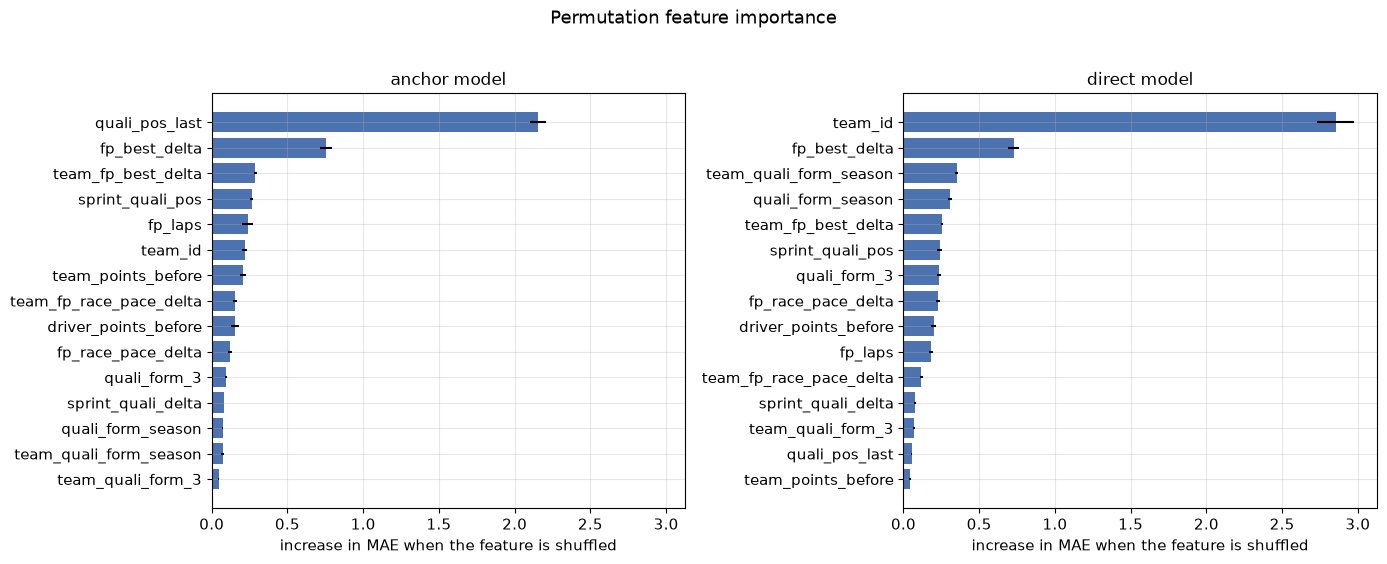

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True)
for ax, model, name in ((axes[0], anchor_model, "anchor model"), (axes[1], direct_model, "direct model")):
    if name == "anchor model":
        target_y = (train_set["quali_pos"] - train_set["quali_pos_last"]).to_numpy(dtype=float)
    else:
        target_y = train_set["quali_pos"].to_numpy(dtype=float)
    imp = permutation_importance(
        model,
        train_set[FEATURES].to_numpy(dtype=float),
        target_y,
        scoring="neg_mean_absolute_error",
        n_repeats=5,
        random_state=42,
    )
    order = np.argsort(imp.importances_mean)
    ax.barh(np.array(FEATURES)[order], imp.importances_mean[order],
            xerr=imp.importances_std[order], color="#4c72b0")
    ax.set(xlabel="increase in MAE when the feature is shuffled", title=name)
fig.suptitle("Permutation feature importance", y=1.02)
fig.tight_layout()
plt.show()

## 8. Takeaways & next steps

- Friday practice is highly informative about Saturday: the fastest clean practice lap is the strongest feature after the qualifying anchor itself, and one-lap pace is far more stable than race results - which is why the backtest errors here are much smaller than for race prediction.
- Grids are sticky: the persistence baseline ("same grid as last weekend") is deceptively strong. The models earn their keep by catching surprise pace-setters and slumpers that Friday data reveals.
- On sprint weekends the sprint-qualifying result is a near-quali preview from Friday and feeds the models directly; the sprint race is excluded because it runs on the same day as GP qualifying.
- Every feature is available the evening before qualifying, so this is exactly the pipeline to run on a Friday night - re-run the notebook after FP2 and again after sprint quali on sprint weekends.

Ideas to extend:

- **FP3 variant**: add the final practice session for a Saturday-morning prediction after FP3.
- **Track evolution**: tyre compound and surface data to correct practice pace for conditions.
- **Driver head-to-head**: teammate quali win-streak features.
- **More seasons**: multi-season training to learn track-type effects.
- **Uncertainty**: quantile regression for pole probabilities instead of a single predicted order.